# 1 - Bibliotecas Utilizadas

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

from imblearn.over_sampling import SMOTE

# Ignorar avisas
import warnings
warnings.filterwarnings('ignore')

# 2 - Dicionário de Dados 

- `udi`: Identificador único numérico para cada registro na base de dados (varia de 1 a 10.000).
- `id_produto`: Código de identificação exclusivo do produto, composto por uma letra que indica a qualidade e um número de série.
- `tipo`: Categoria do equipamento baseada na sua especificação técnica, sendo dividido em três classes: L (Low - Baixo), M (Medium - Médio) ou H (High - Alto).
- `temperatura_ar_k`: Temperatura do ambiente onde a máquina está instalada, medida na escala Kelvin.
- `temperatura_processo_k`: Temperatura gerada durante a operação do processo de fabricação, medida na escala Kelvin.
- `velocidade_rotacao_rpm`: Velocidade de giro do motor do equipamento, medida em Rotações Por Minuto (RPM).
- `torque_nm`: Força de torção gerada pelo motor da máquina, medida em Newton-metro (Nm).
desgaste_ferramenta_min: Tempo acumulado de utilização da ferramenta de corte atual, medido em minutos.
- `falha_maquina`: Variável Alvo (Target) do projeto. Indica o estado de operação do equipamento, onde 1 representa que a máquina sofreu uma falha mecânica e 0 representa que a máquina operou normalmente.


#### **Nota:** As colunas listadas abaixo representam os motivos técnicos específicos que geraram a quebra da máquina. Elas servem apenas para consulta de histórico e não devem ser utilizadas como variáveis preditoras (X) durante o treinamento dos modelos:

- `falha_twf`: Falha por desgaste da ferramenta (Tool Wear Failure - 1 para sim, 0 para não).
- `falha_hdf`: Falha por dissipação de calor/superaquecimento (Heat Dissipation Failure - 1 para sim, 0 para não).
- `falha_pwf`: Falha por falta ou excesso de potência elétrica (Power Failure - 1 para sim, 0 para não).
- `falha_osf`: Falha por esforço ou tensão mecânica excessiva (Overstrain Failure - 1 para sim, 0 para não).
- `falha_rnf`: Falha aleatória não detectada pelos sensores padrão (Random Failure - 1 para sim, 0 para não).

# 3 - Limpeza e tratamento dos dados

## 3.1 - Carregamento e Overview dos dados

In [2]:
# Carregamento global do diretório
pasta_atual = Path().resolve()

In [3]:
# Importando dados do google drive
id_arquivo = '1DVYqjYhbrn5lzUUBtSyGlxn6xikO8n5c'
link = f'https://drive.google.com/uc?id={id_arquivo}'

dados = pd.read_csv(link)

# Salvando dados brutos na camada bronze
pasta_raw = pasta_atual.parent / 'data' / '1_bronze'
pasta_raw.mkdir(parents=True, exist_ok=True)

caminho_arquivo = pasta_raw / 'manutencao_preditiva.csv'

dados.to_csv(caminho_arquivo, index=False)

O salvamento dos dados brutos na camada Bronze faz parte do conceito de data lineage (linhagem de dados), ou seja, preserva a origem das informações para garantir a rastreabilidade de todo o ciclo de vida dos dados e de suas transformações para futuras auditorias. O projeto adotará o conceito de arquitetura medalhão:

- Bronze: dados brutos.
- Silver: dados limpos e integrados (sanitizados).
- Gold: dados agregados e prontos para consumo.

In [4]:
# Cópia dos dataframe
df = dados.copy()

In [5]:
# Primeiras 5 linhas
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [6]:
# Ultimas 5 Linhas
df.tail()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500.0,40.2,30,0,0,0,0,0,0


In [7]:
# Shape do dataframe
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

Quantidade de linhas: 10000
Quantidade de colunas: 14


In [8]:
# Iformações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

In [9]:
# Verificação de nulos
df.isnull().sum().sort_values(ascending = False)

temperatura_processo_k     500
temperatura_ar_k           500
velocidade_rotacao_rpm     500
torque_nm                  500
id_produto                   0
udi                          0
tipo                         0
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [10]:
# Verificação de duplicidade do ID
print(f'Total de registros: {df['udi'].value_counts().sum()}')
print (f'Valores únicos variavel "udi": {df['udi'].nunique()}')

Total de registros: 10000
Valores únicos variavel "udi": 10000


## Relatório Overview

A base contém 10.000 registros e 14 variáveis. Não há identificadores duplicados e em principio o tipos de dados estão corretos. Porém contem 500 valores ausentes em cada uma das 4 variáveis abaixo:

- temperatura_processo_k
- temperatura_ar_k
- velocidade_rotacao_rpm
- torque_nm

## 3.2 - Tratamento de nulos

In [11]:
# Verificando quantidade de registros em que as colunas possuem nulo ao mesmo tempo, caso resultado seja 500
# significa que são sempre ao mesmo tempo
colunas = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

print(f'Registros ausentes concomitantes: {df[colunas].isna().all(axis=1).sum()}')

Registros ausentes concomitantes: 500


In [12]:
# Criando um df dos nulos
df_nulos = df[df['temperatura_ar_k'].isnull()]
len(df_nulos)

500

In [13]:
# Primeiras 30 linhas com valores nulos
df_nulos.head(30)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0
35,36,M14895,M,NaN,NaN,NaN,NaN,98,0,0,0,0,0,0
39,40,L47219,L,NaN,NaN,NaN,NaN,111,0,0,0,0,0,0
76,77,L47256,L,NaN,NaN,NaN,NaN,206,0,0,0,0,0,0
80,81,H29494,H,NaN,NaN,NaN,NaN,4,0,0,0,0,0,0
88,89,M14948,M,NaN,NaN,NaN,NaN,27,0,0,0,0,0,0


In [14]:
# Verificando quantidade de valores ausentes contêm ou não falhas

falha = len(df_nulos[df_nulos['falha_maquina'] == 1])
sem_falha = len(df_nulos[df_nulos['falha_maquina'] == 0])

print(f'Quantidade de valores ausentes com falha: {falha}')
print(f'Quantidade de valores ausentes sem falha: {sem_falha}')
print(f'Proporção dos valores ausentes que contêm falha: {round(falha/500, 2) * 100}% ')

Quantidade de valores ausentes com falha: 17
Quantidade de valores ausentes sem falha: 483
Proporção dos valores ausentes que contêm falha: 3.0% 


### `Estratégia Adotada`

Optei por remover os registros com valores ausentes (5% da base) em vez de imputá-los. Essa decisão se baseia no fato de que os valores nulos ocorrem simultaneamente em 4 das 6 variáveis preditoras. Como apenas 3% desses casos representam falhas, a imputação tem chances minimas de ganho performático para o modelo, aumentaria o custo de processamento e, o mais crítico, introduziria risco de viés (distorção) nos dados.

In [15]:
# Removendo valores ausentes
df_novo = df.dropna()
df_novo

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


In [16]:
df_novo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      9500 non-null   int64  
 1   id_produto               9500 non-null   object 
 2   tipo                     9500 non-null   object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  9500 non-null   int64  
 8   falha_maquina            9500 non-null   int64  
 9   falha_twf                9500 non-null   int64  
 10  falha_hdf                9500 non-null   int64  
 11  falha_pwf                9500 non-null   int64  
 12  falha_osf                9500 non-null   int64  
 13  falha_rnf                9500 non-null   int64  
dtypes: float64(4), int64(8), obje

## 3.3 - Salvamento na camada Silver

In [17]:
pasta_silver = pasta_atual.parent / 'data' / '2_silver'
pasta_silver.mkdir(parents=True, exist_ok=True)

caminho_silver = pasta_silver / 'manutencao_preditiva-silver.csv'

df_novo.to_csv(caminho_silver, index=False)

# 4 - Análise Exploratória

In [18]:
# Caminho para salvamento dos graficos
pasta_graficos = pasta_atual.parent / 'outputs' / 'graficos'
pasta_graficos.mkdir(parents=True, exist_ok=True)

## 4.1 - Carregamento dos dados da camada Silver

In [19]:
pasta_silver = pasta_atual.parent / 'data' / '2_silver'
pasta_silver.mkdir(parents=True, exist_ok=True)

caminho_silver = pasta_silver / 'manutencao_preditiva-silver.csv'

dados = pd.read_csv(caminho_silver)

df = dados.copy()

df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
4,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      9500 non-null   int64  
 1   id_produto               9500 non-null   object 
 2   tipo                     9500 non-null   object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  9500 non-null   int64  
 8   falha_maquina            9500 non-null   int64  
 9   falha_twf                9500 non-null   int64  
 10  falha_hdf                9500 non-null   int64  
 11  falha_pwf                9500 non-null   int64  
 12  falha_osf                9500 non-null   int64  
 13  falha_rnf                9500 non-null   int64  
dtypes: float64(4), int64(8),

In [21]:
# Visão estatistica geral
df.describe(include = 'all')

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,9500.000000,9500,9500,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000
unique,NaN,9500,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,5678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5001.853368,NaN,NaN,300.002158,310.000895,1539.245263,39.974168,108.085579,0.033895,0.004421,0.011474,0.009579,0.010000,0.002000
std,2887.840374,NaN,NaN,2.001689,1.486432,180.273589,9.995453,63.584962,0.180968,0.066347,0.106505,0.097407,0.099504,0.044679
min,1.000000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2496.750000,NaN,NaN,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4997.500000,NaN,NaN,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7499.250000,NaN,NaN,301.500000,311.100000,1613.000000,46.700000,162.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 4.2 Análises univariadas

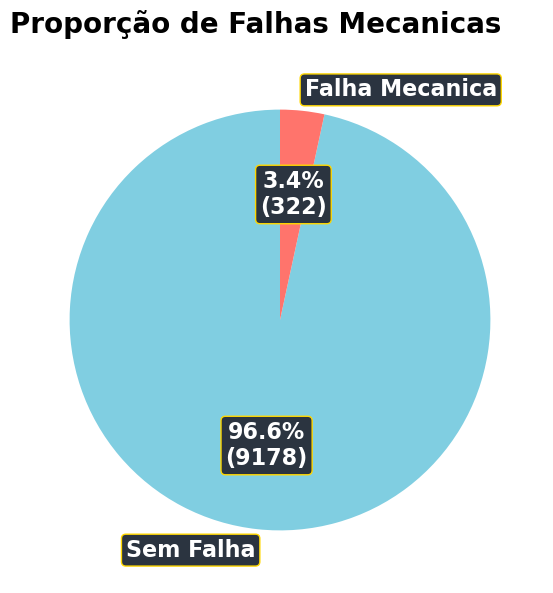

In [22]:
# Distribuição da variavel target (falha_maquina)

fig, ax = plt.subplots(figsize = (18, 6))
fig.suptitle('Proporção de Falhas Mecanicas', fontsize = 20, fontweight = 'bold', x=0.35,  ha='left')

ax.pie(df['falha_maquina'].value_counts(),
        labels = df['falha_maquina'].value_counts().index.map({0 : 'Sem Falha', 1 : 'Falha Mecanica'}),
        autopct = lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(df['falha_maquina'].value_counts()))})',
        startangle = 90,
        colors=['#80cee1','#FF746c'],
        textprops = {
            'color' : 'white',
            'fontsize' : 16,
            'fontweight': 'bold',
            'bbox': { 
                    'boxstyle': 'round',
                    'edgecolor': 'gold',
                    'facecolor': '#2b3440',
                    'linewidth': 1,
                    'pad': 0.2
            }           
        }    
       )

plt.savefig(pasta_graficos/'distribuição_target.png', dpi = 300, bbox_inches = 'tight')

plt.tight_layout()

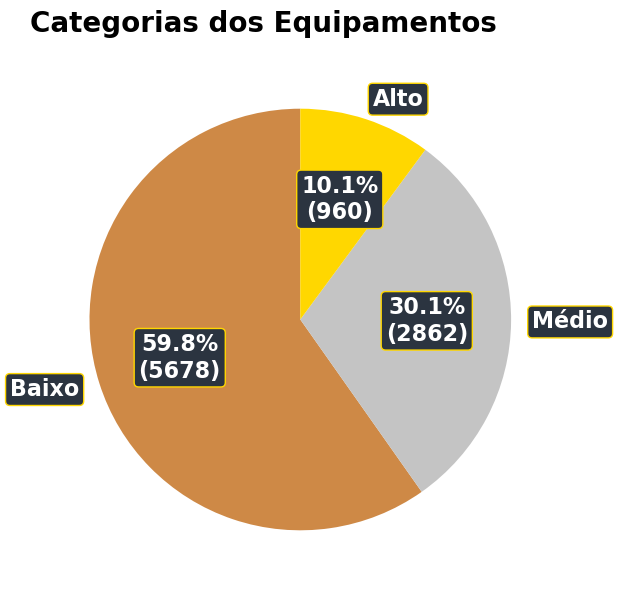

In [23]:
# Distribuição da variavel tipo

fig, ax = plt.subplots(figsize = (18, 6))
fig.suptitle('Categorias dos Equipamentos', fontsize = 20, fontweight = 'bold', x=0.35,  ha='left')

ax.pie(df['tipo'].value_counts(),
        labels = df['tipo'].value_counts().index.map({'L' : 'Baixo', 'M' : 'Médio', 'H': 'Alto'}),
        autopct = lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(df['falha_maquina'].value_counts()))})',
        startangle = 90,
        colors=['#ce8946','#C4C4C4','#FFD700'],
        textprops = {
            'color' : 'white',
            'fontsize' : 16,
            'fontweight': 'bold',
            'bbox': { 
                    'boxstyle': 'round',
                    'edgecolor': 'gold',
                    'facecolor': '#2b3440',
                    'linewidth': 1,
                    'pad': 0.2
            }           
        }    
       )

plt.savefig(pasta_graficos/'distribuição_tipo.png', dpi = 300, bbox_inches = 'tight')
plt.tight_layout()

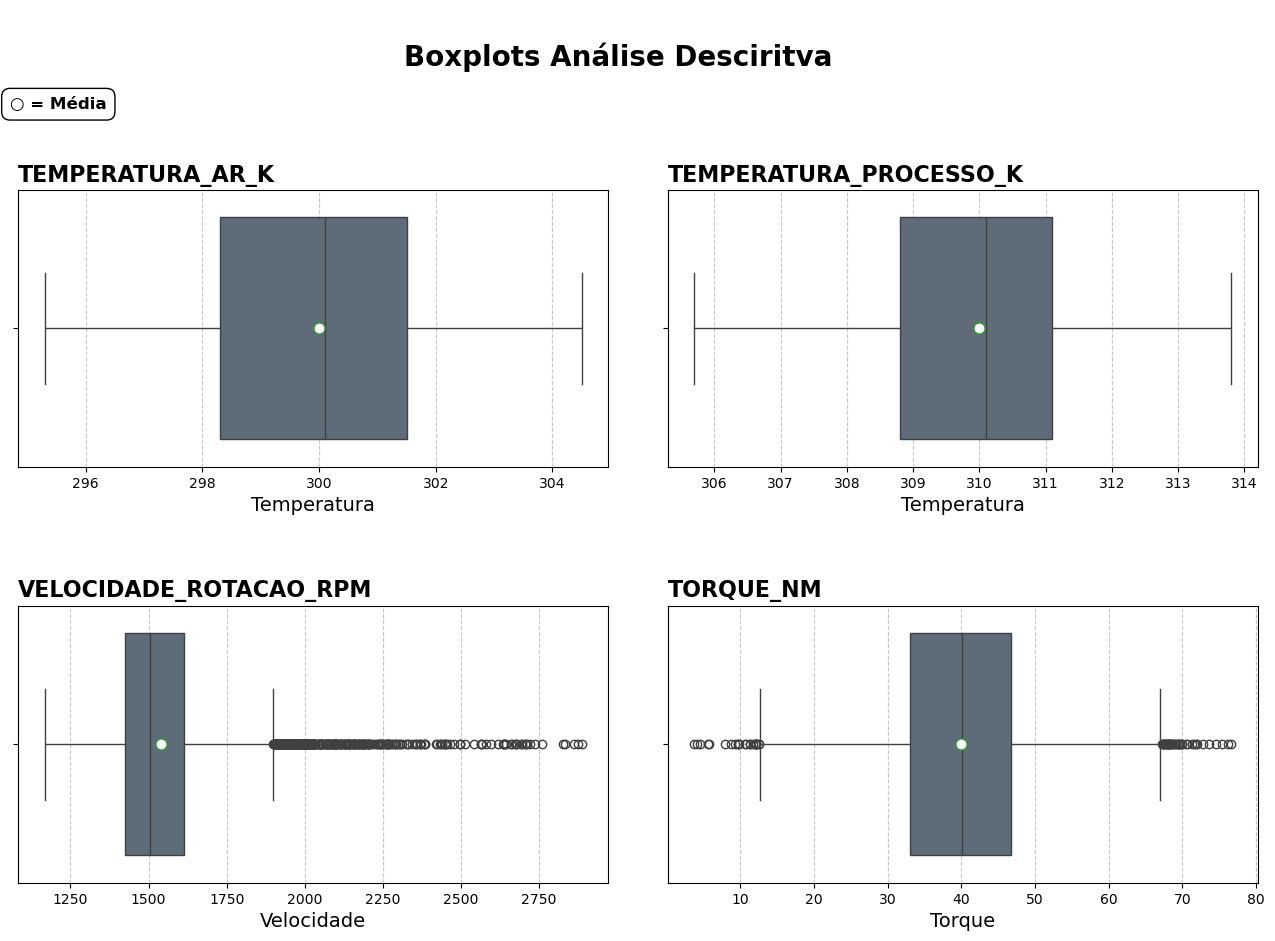

In [24]:
colunas = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

fig, axs = plt.subplots(2,2, figsize = (16,9))
fig.subplots_adjust(hspace = 0.5, wspace = 0.1)
fig.suptitle('\nBoxplots Análise Desciritva', fontsize = 20,  fontweight = 'bold', y=1.08)

for i, k in zip(axs.ravel(), colunas):
    sns.boxplot(
        data = df,
        x = k,
        color = '#5A6B7C',
        ax = i,
        showmeans=True,
        meanprops={'marker':'o', 'markerfacecolor':'white', 'markersize':'8'})
    
    i.set_title(f'{k.upper()}', fontsize = 16, fontweight = 'bold', loc = 'left')
    i.grid(axis='x', linestyle='--', alpha=0.7)


fig.text(
    0.12,  
    0.97,  
    "○ = Média", 
    fontsize=12, 
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

axs[0,0].set_xlabel('Temperatura', fontsize = 14)
axs[0,1].set_xlabel('Temperatura', fontsize = 14)
axs[1,0].set_xlabel('Velocidade', fontsize = 14)
axs[1,1].set_xlabel('Torque', fontsize = 14)

plt.savefig(pasta_graficos/'boxplot_temperaturas_rpm_torque.png', dpi = 300, bbox_inches = 'tight')
plt.show()

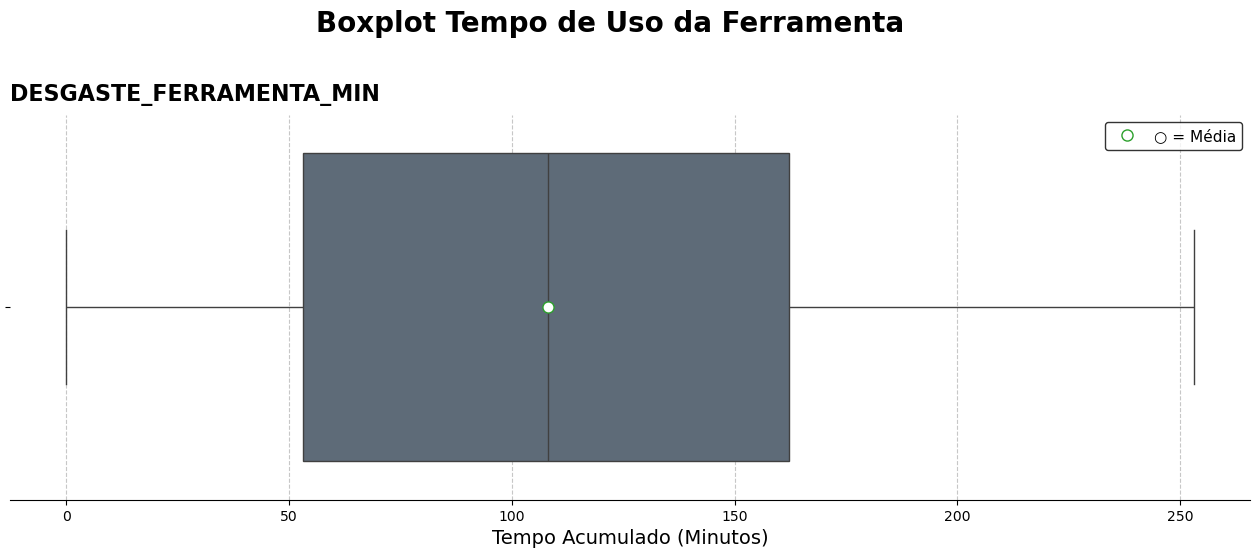

In [25]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Boxplot Tempo de Uso da Ferramenta', fontsize=20, fontweight='bold', y=1.09)

sns.boxplot(
    data=df,
    x='desgaste_ferramenta_min',
    ax=ax,
    color = '#5A6B7C',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'white', 'markersize': '8', 'label': '○ = Média'}
)

ax.set_title('DESGASTE_FERRAMENTA_MIN', fontsize=16, fontweight='bold', loc='left', pad=10)
ax.set_xlabel('Tempo Acumulado (Minutos)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='black', fontsize=11)

sns.despine(left=True)

plt.savefig(pasta_graficos/'boxplot_desgaste_ferramenta.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## 4.3 - Análises bivariadas

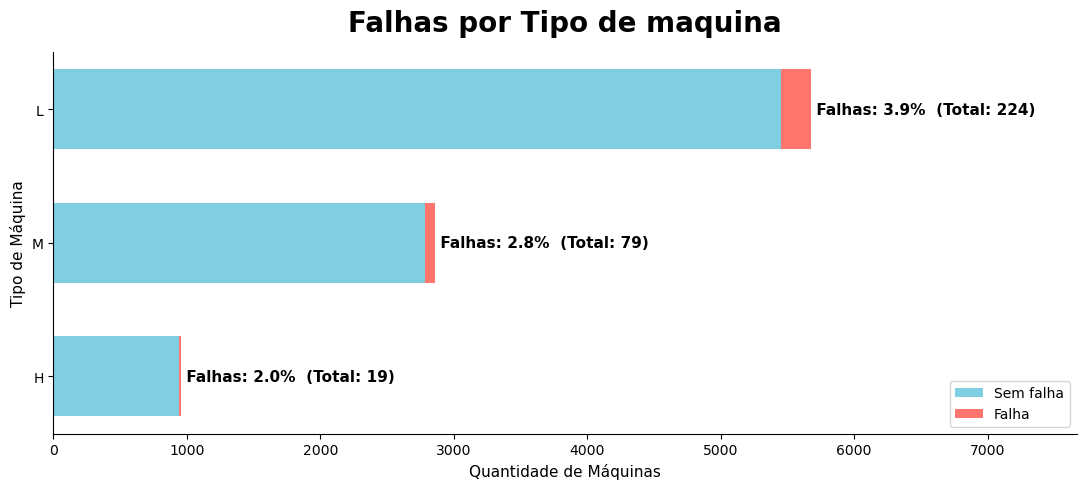

In [26]:
resumo = (
    df.groupby("tipo")
    .agg(
        total_maquinas=("falha_maquina", "count"),
        total_falhas=("falha_maquina", "sum"),
    )
    .reset_index()
)

resumo["sem_falhas"] = resumo["total_maquinas"] - resumo["total_falhas"]
resumo["proporcao_falha"] = (resumo["total_falhas"] / resumo["total_maquinas"]) * 100
resumo = resumo.sort_values(by="total_maquinas", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))

barras_ok = ax.barh(
    resumo["tipo"],
    resumo["sem_falhas"],
    color="#80cee1",  
    height=0.6,
    label="Sem falha",
)

barras_falha = ax.barh(
    resumo["tipo"],
    resumo["total_falhas"],
    left=resumo["sem_falhas"],  
    color="#FF746c",  
    height=0.6,
    label="Falha",
)

for barra, falha_pct, total in zip(
    barras_falha, resumo["proporcao_falha"], resumo["total_falhas"]
):
    fim_da_barra = barra.get_x() + barra.get_width()

    texto_rotulo = f" Falhas: {falha_pct:.1f}%  (Total: {total})"

    ax.text(
        fim_da_barra,  
        barra.get_y() + barra.get_height() / 2,  
        texto_rotulo,
        va="center",
        ha="left",
        fontsize=11,
        weight="bold",
    )

ax.set_title("Falhas por Tipo de maquina", fontsize=20,fontweight = 'bold', pad=15)
ax.set_xlabel("Quantidade de Máquinas", fontsize=11)
ax.set_ylabel("Tipo de Máquina", fontsize=11)

ax.set_xlim(0, resumo["total_maquinas"].max() * 1.35)

ax.legend(loc="lower right")

for espinha in ["top", "right"]:
    ax.spines[espinha].set_visible(False)

plt.tight_layout()

plt.savefig(pasta_graficos/'falha_p_tipo_maquina.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Embora as máquinas do tipo L apresentem o dobro da proporção de falhas em comparação ao tipo H, existe um forte desbalanceamento na base: o volume do tipo L é cerca de 6 vezes maior. Além disso, o gráfico sugere uma correlação positiva entre o volume de equipamentos e a taxa de falhas. Esse cenário torna difícil inferir, apenas com esta visualização, se as falhas são causadas pelo tipo da máquina ou se são um reflexo do desbalanceamento de volume.

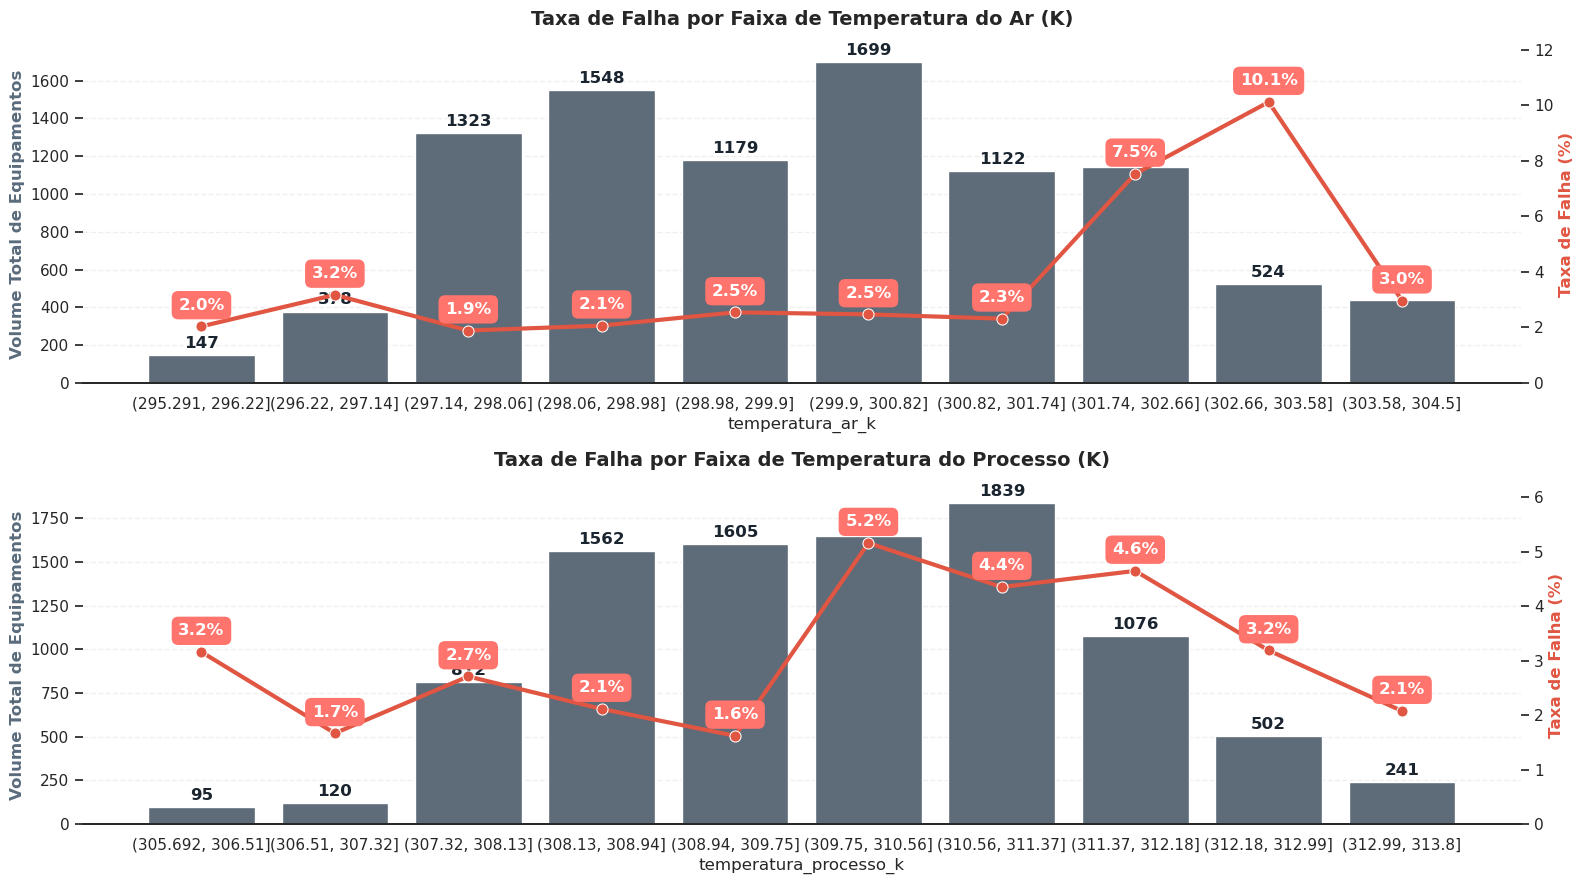

In [27]:
sns.set_theme(style="white", rc={"figure.figsize": (16, 9)})
fig, axs = plt.subplots(2, 1, sharex=False)

cols = ["temperatura_ar_k", "temperatura_processo_k"]
titulos = ["Taxa de Falha por Faixa de Temperatura do Ar (K)", "Taxa de Falha por Faixa de Temperatura do Processo (K)"]

for i, col in enumerate(cols):
    ax1 = axs[i]

    df_bin = df.groupby(pd.cut(df[col], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
    df_bin[col] = df_bin[col].astype(str)
    df_bin["taxa_pct"] = df_bin["mean"] * 100  

    sns.barplot(data=df_bin, x=col, y="count", color="#5A6B7C", ax=ax1)
    ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
    ax1.set_title(titulos[i], fontsize=14, pad=15, fontweight="bold")
    ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

    ax2 = ax1.twinx()
    sns.lineplot(data=df_bin, x=col, y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
    ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

    ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2)

    for idx, row in df_bin.iterrows():
        ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                     xytext=(0,12), ha='center', color='white', fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))

    ax1.spines[['top', 'left', 'right']].set_visible(False)
    ax2.spines[['top', 'left', 'right']].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(pasta_graficos/'falha_p_temperaturas.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Em relação à temperatura do ar, a taxa de falhas apresenta um salto evidente de 2,3% para 10,1% na faixa entre 301K e 303K. Acima de 303K, porém, essa taxa cai abruptamente para 3%. Esse pico sugere uma correlação em uma faixa térmica específica, mas não define causalidade.

Já na temperatura do processo, o comportamento também não é linear. Observa-se uma elevação de 1,6% para 5,2% entre 309K e 310K, mantendo-se acima de 4% até 312K. Após esse pico, a taxa recua para 2,1% aos 313K. Além disso, as temperaturas mais baixas (305K a 306K) apresentam 3,2% de falhas, mas possuem uma baixíssima volumetria (apenas 95 registros). Essa quebra de linearidade e a variação no volume da amostra tornam difícil estabelecer visualmente uma relação causal direta entre a temperatura do processo e as falhas no equipamento.

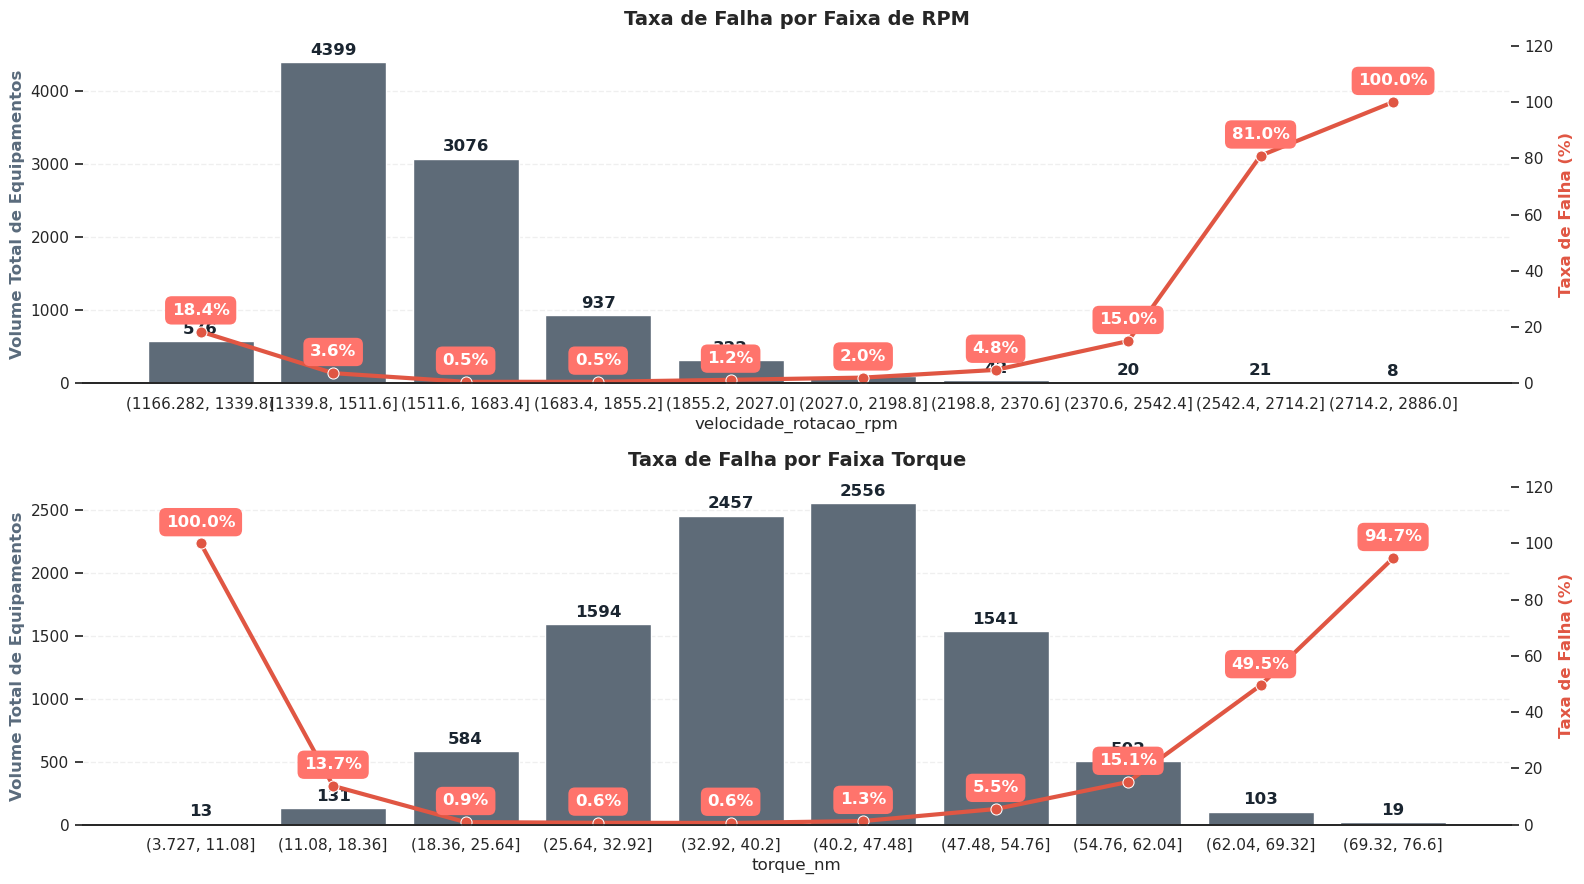

In [28]:
fig, axs = plt.subplots(2, 1, sharex=False)

cols = ["velocidade_rotacao_rpm", "torque_nm"]
titulos = ["Taxa de Falha por Faixa de RPM", "Taxa de Falha por Faixa Torque"]

for i, col in enumerate(cols):
    ax1 = axs[i]

    df_bin = df.groupby(pd.cut(df[col], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
    df_bin[col] = df_bin[col].astype(str)
    df_bin["taxa_pct"] = df_bin["mean"] * 100  

    sns.barplot(data=df_bin, x=col, y="count", color="#5A6B7C", ax=ax1)
    ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
    ax1.set_title(titulos[i], fontsize=14, pad=15, fontweight="bold")
    ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

    ax2 = ax1.twinx()
    sns.lineplot(data=df_bin, x=col, y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
    ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

    ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2)

    for idx, row in df_bin.iterrows():
        ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                     xytext=(0,12), ha='center', color='white', fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))

    ax1.spines[['top', 'left', 'right']].set_visible(False)
    ax2.spines[['top', 'left', 'right']].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(pasta_graficos/'falha_p_torque_RPM.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Tanto o RPM quanto o Torque apresentam uma baixa proporção de falhas quando operam em torno de suas médias (1.539 e 40, respectivamente). À medida que os valores se distanciam desse centro — seja para mais ou para menos —, a taxa de falhas sobe de forma consistente. Esse comportamento sugere a existência de uma faixa ideal de operação: operar o equipamento fora desses limites térmicos e mecânicos aumenta consideravelmente a probabilidade de quebra, indicando uma forte relação de causa e efeito.

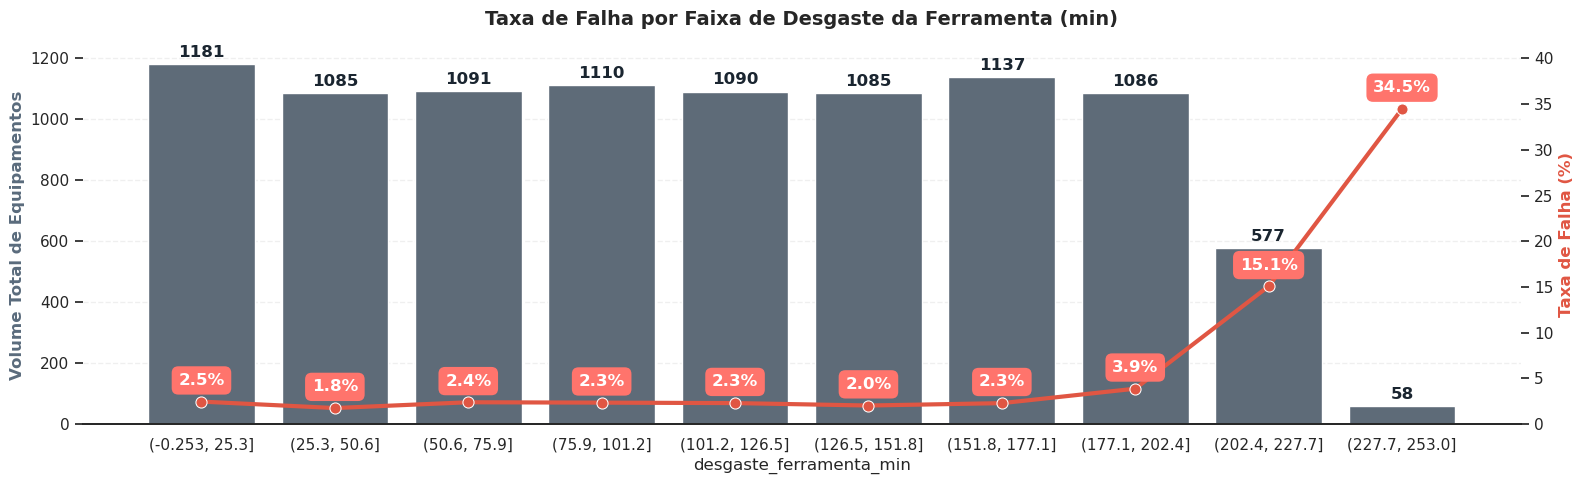

In [29]:
fig, ax1 = plt.subplots(figsize=(16, 5))

df_bin = df.groupby(pd.cut(df["desgaste_ferramenta_min"], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
df_bin["desgaste_ferramenta_min"] = df_bin["desgaste_ferramenta_min"].astype(str)
df_bin["taxa_pct"] = df_bin["mean"] * 100

sns.barplot(data=df_bin, x="desgaste_ferramenta_min", y="count", color="#5A6B7C", ax=ax1)
ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
ax1.set_title("Taxa de Falha por Faixa de Desgaste da Ferramenta (min)", fontsize=14, pad=15, fontweight="bold")
ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

ax2 = ax1.twinx()
sns.lineplot(data=df_bin, x="desgaste_ferramenta_min", y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2 if df_bin["taxa_pct"].max() > 0 else 10)

for idx, row in df_bin.iterrows():
    ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                 xytext=(0,12), ha='center', color='white', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))
    
ax1.spines[['top', 'left', 'right']].set_visible(False)
ax2.spines[['top', 'left', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(pasta_graficos/'falha_p_desgaste.png', dpi = 300, bbox_inches = 'tight')
plt.show()

O gráfico revela um claro ponto de virada (limiar de desgaste) relacionado ao tempo de uso. Em operações de até 177 minutos, a taxa de falhas é estável e baixa, na casa dos 2,3%. No entanto, após cruzar esse limite, a probabilidade de falha aumenta drasticamente, atingindo um pico de 34,5% em operações que ultrapassam a marca de 227 minutos.

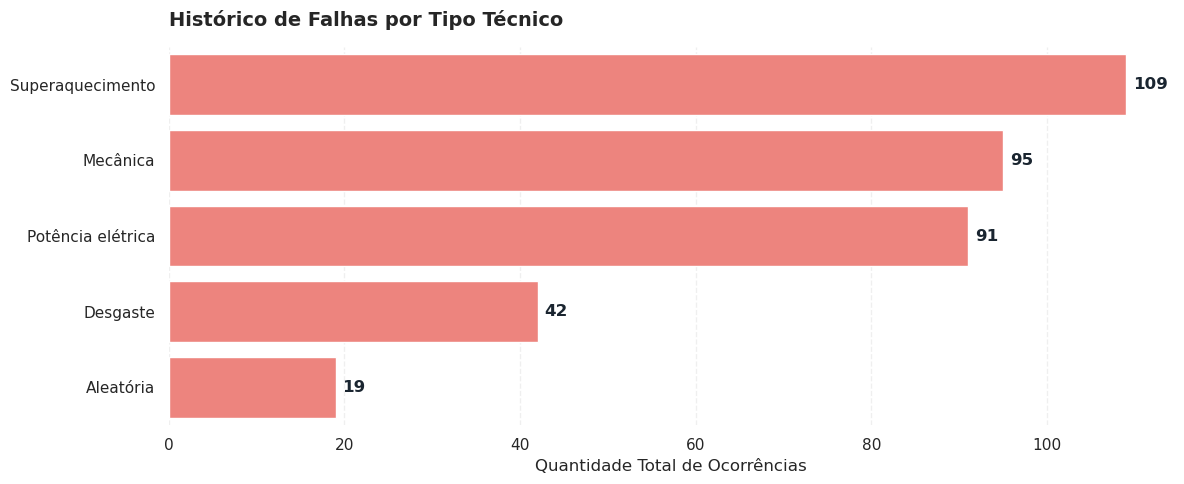

In [30]:
colunas_falha = ['falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
nomes_corretos = {'falha_twf': 'Desgaste', 'falha_hdf': 'Superaquecimento', 'falha_pwf': 'Potência elétrica', 'falha_osf': 'Mecânica', 'falha_rnf': 'Aleatória'}

df_falhas = df[colunas_falha].sum().rename(nomes_corretos).sort_values(ascending=False).reset_index()
df_falhas.columns = ['Tipo de Falha', 'Total']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_falhas, x='Total', y='Tipo de Falha', color='#FF746c', ax=ax)

ax.set_title('Histórico de Falhas por Tipo Técnico', fontsize=14, pad=15, fontweight='bold', loc='left')
ax.set_xlabel('Quantidade Total de Ocorrências', fontsize=12)
ax.set_ylabel('') # Remove o título do eixo Y já que os nomes são autoexplicativos
ax.bar_label(ax.containers[0], padding=5, color='#1A2530', fontweight='bold')

sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(pasta_graficos/'tipo_de_falha.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# 5 - Feature Engineering e Análise

## 5.1 Feature Engineering

df.head()

### ALteções que serão realizadas

- **Criação de variaveis**:
    - `potencia_kw` : Apartir das colunas velocidade_rotacao_rpm e torque_nm obeter a potencia em Quilowatts $$Potência\ (kW) = \frac{2 \cdot \pi \cdot Torque\ (Nm) \cdot Velocidade\ (RPM)}{60 \cdot 1000}$$
    - `delta_temperatura` : Diferença da temperatura ambiente para temperatura do processo temperatura_ar_k - temperatura_processo_k
- **Ordinal Encoding**:
    - `tipo`: Por se tratar de uma variavel `categorica ordinal` os valores L, M e H serão alterados para 1, 2 e 3 respectivamente, garantindo sua aceitação pelo modelo de machine learnig futuramente

In [31]:
# Copia do df atual
df_novo = df.copy()
df_novo.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
4,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0


In [32]:
# Criação da coluna potencia
pi_val = np.pi
df_novo['potencia_kw'] = df_novo.eval('(velocidade_rotacao_rpm * torque_nm * (2 * @pi_val / 60))/ 1000')
df_novo[['velocidade_rotacao_rpm', 'torque_nm', 'potencia_kw']]

,velocidade_rotacao_rpm,torque_nm,potencia_kw
0,1551.0,42.8,6.951591
1,1408.0,46.3,6.826723
2,1498.0,49.4,7.749388
3,1408.0,40.0,5.897817
4,1425.0,41.9,6.252555
...,...,...,...
9495,1604.0,29.5,4.955129
9496,1632.0,31.8,5.434704
9497,1645.0,33.4,5.753618
9498,1408.0,48.5,7.151103


In [33]:
# Criação coluna delta_temperatura
df_novo['delta_temperatura'] = df_novo.eval('temperatura_ar_k - temperatura_processo_k') 
df_novo[['temperatura_ar_k', 'temperatura_processo_k', 'delta_temperatura']]

,temperatura_ar_k,temperatura_processo_k,delta_temperatura
0,298.1,308.6,-10.5
1,298.2,308.7,-10.5
2,298.1,308.5,-10.4
3,298.2,308.7,-10.5
4,298.1,308.6,-10.5
...,...,...,...
9495,298.8,308.4,-9.6
9496,298.9,308.4,-9.5
9497,299.0,308.6,-9.6
9498,299.0,308.7,-9.7


In [34]:
# Ordinal encoding coluna tipo
df_novo['tipo'] = df_novo['tipo'].map({'L': 1, 'M': 2, 'H': 3}) 
df_novo['tipo']

0       2
1       1
2       1
3       1
4       2
       ..
9495    2
9496    3
9497    2
9498    3
9499    2
Name: tipo, Length: 9500, dtype: int64

In [35]:
df_novo.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia_kw,delta_temperatura
0,1,M14860,2,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,6.951591,-10.5
1,2,L47181,1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,6.826723,-10.5
2,3,L47182,1,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,7.749388,-10.4
3,5,L47184,1,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,5.897817,-10.5
4,6,M14865,2,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0,6.252555,-10.5


In [36]:
df_novo.dtypes

udi                          int64
id_produto                  object
tipo                         int64
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
potencia_kw                float64
delta_temperatura          float64
dtype: object

## 5.2 Análises pós Feature Engineering

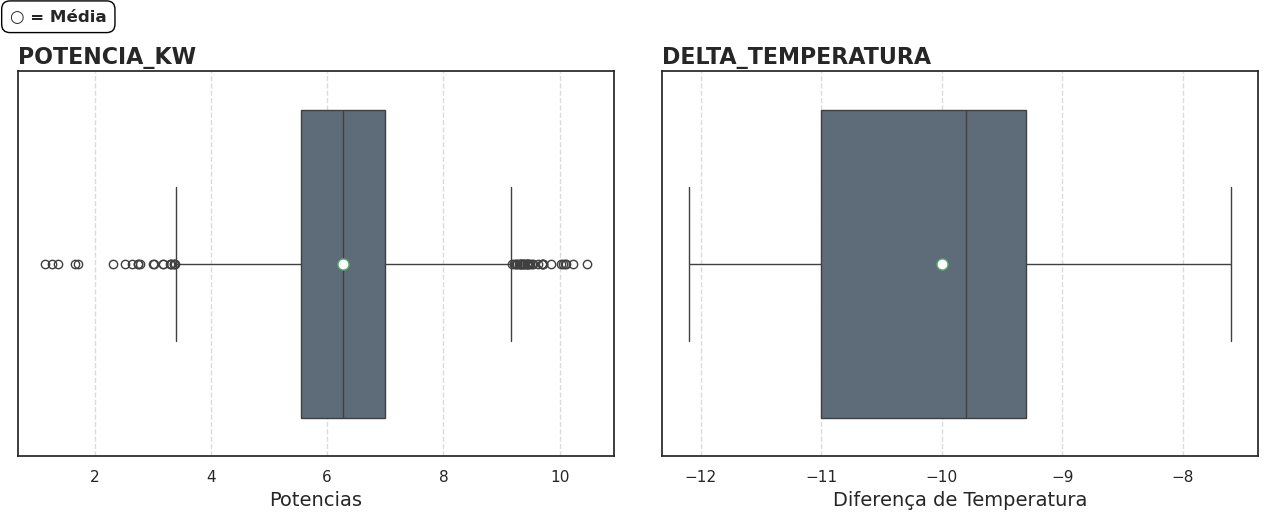

In [37]:
colunas = ['potencia_kw', 'delta_temperatura']

fig, axs = plt.subplots(1,2, figsize = (16,5))
fig.subplots_adjust(hspace = 0.5, wspace = 0.08)

for i, k in zip(axs.ravel(), colunas):
    sns.boxplot(
        data = df_novo,
        x = k,
        color = '#5A6B7C',
        ax = i,
        showmeans=True,
        meanprops={'marker':'o', 'markerfacecolor':'white', 'markersize':'8'})
    
    i.set_title(f'{k.upper()}', fontsize = 16, fontweight = 'bold', loc = 'left')
    i.grid(axis='x', linestyle='--', alpha=0.7)


fig.text(
    0.12,  
    0.98,  
    "○ = Média", 
    fontsize=12, 
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

axs[0].set_xlabel('Potencias', fontsize = 14)
axs[1].set_xlabel('Diferença de Temperatura', fontsize = 14)

plt.savefig(pasta_graficos/'boxplot_potencia_deltaK.png', dpi = 300, bbox_inches = 'tight')
plt.show()

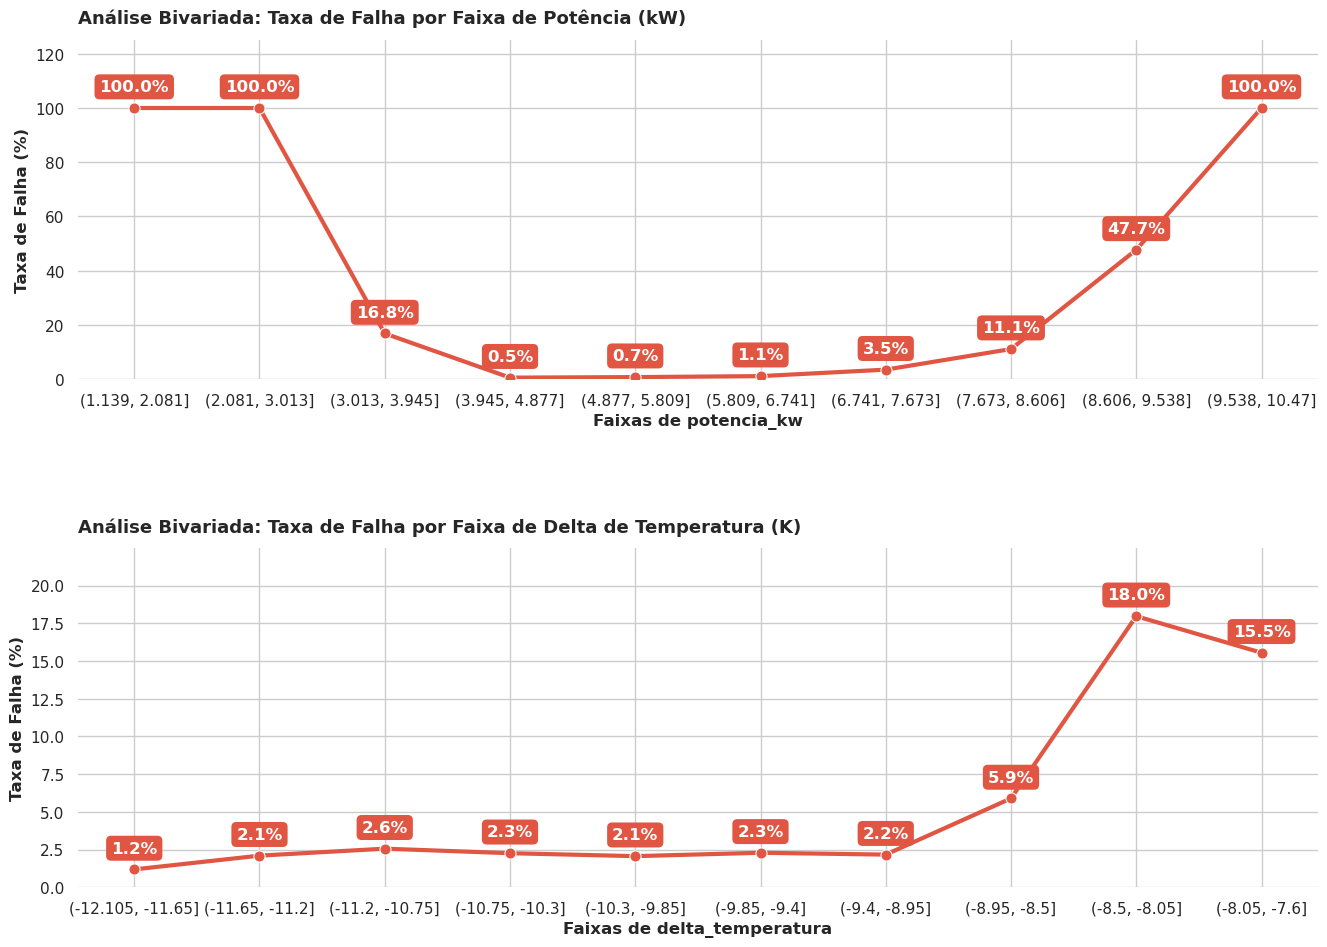

In [38]:
sns.set_theme(style="whitegrid", rc={"figure.figsize": (16, 11)})
fig, axs = plt.subplots(2, 1, sharex=False)
fig.subplots_adjust(hspace=0.5) 

recursos = ["potencia_kw", "delta_temperatura"]
titulos = [
    "Análise Bivariada: Taxa de Falha por Faixa de Potência (kW)",
    "Análise Bivariada: Taxa de Falha por Faixa de Delta de Temperatura (K)"
]

for i, col in enumerate(recursos):
    ax = axs[i]   

    df_bin = df_novo.groupby(pd.cut(df_novo[col], bins=10), observed=False)["falha_maquina"].mean().reset_index()
    df_bin[col] = df_bin[col].astype(str)
    df_bin["taxa_pct"] = df_bin["falha_maquina"] * 100

    sns.lineplot(data=df_bin, x=col, y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax)

    ax.set_title(titulos[i], fontsize=13, pad=12, fontweight="bold", loc="left")
    ax.set_ylabel("Taxa de Falha (%)", fontweight="bold")
    ax.set_xlabel(f"Faixas de {col}", fontweight="bold")
    ax.set_ylim(0, df_bin["taxa_pct"].max() * 1.25 if df_bin["taxa_pct"].max() > 0 else 10)

    for idx, row in df_bin.iterrows():
        ax.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                    xytext=(0, 12), ha='center', color='white', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="#E05643", ec="none"))

    sns.despine(ax=ax, left=True, bottom=True)

plt.savefig(pasta_graficos/'falha_p_potencia_deltaK.png', dpi = 300, bbox_inches = 'tight')
plt.show()

A análise de potência revela uma faixa clara de operação segura entre 4 e 6,8 kW, com as falhas oscilando em patamares muito baixos (entre 0,5% e 1,1%). Fora desse intervalo, o risco cresce de forma acentuada, podendo atingir 100% de falha no equipamento.

Já em relação à diferença de temperatura, nota-se que na faixa de -12 a -9 as falhas se mantêm contidas entre 1,2% e 2,2%. Valores fora desse limite (abaixo de -9) provocam um aumento drástico nas quebras, atingindo taxas de até 18%.

# 6 - Preparação dos dados para a Gold

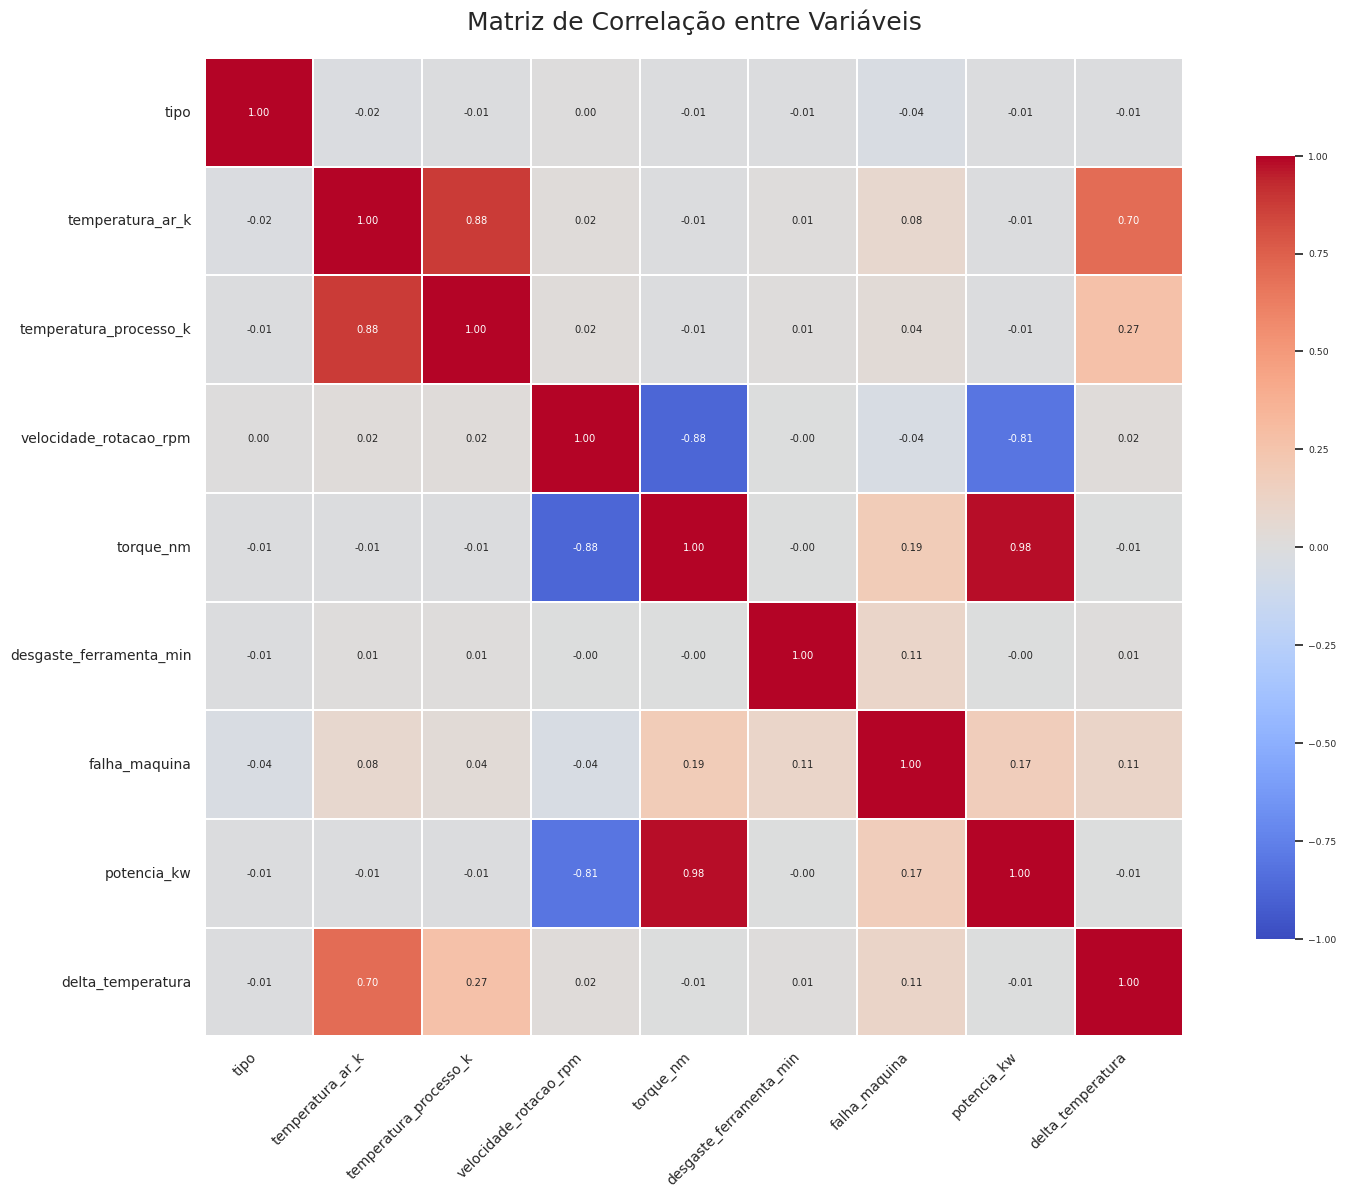

In [39]:
# Verificação de colinariedade entre variaveis.
colunas = ['tipo',
           'temperatura_ar_k',
           'temperatura_processo_k',
           'velocidade_rotacao_rpm',
           'torque_nm',
           'desgaste_ferramenta_min',
           'falha_maquina',
           'potencia_kw',
           'delta_temperatura']

plt.figure(figsize=(16, 12)) 
sns.set(font_scale=0.6)

corr = df_novo[colunas].corr()

heatmap = sns.heatmap(
    corr,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    vmin = -1,
    vmax = 1,
    linewidths = 0.2,
    square = True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação entre Variáveis', pad = 20, fontsize = 18)
plt.xticks(rotation = 45, ha = 'right', fontsize = 10)
plt.yticks(rotation = 0, fontsize = 10)

plt.tight_layout()
plt.show()

## 6.1. Seleção de Variáveis (Feature Selection)
Serão adotadas práticas para minimizar ruídos e melhorar a capacidade de generalização do modelo de Machine Learning. A estratégia consiste em remover variáveis altamente correlacionadas entre si (multicolinearidade) e eliminar colunas que causem data leakage (vazamento de dados).

### Tratamento de Colinearidade

- `velocidade_rotacao_rpm`, `torque_nm` e `potencia_kw`: Devido à alta colinearidade entre elas, será mantida apenas a que possui maior correlação com a variável alvo (target): `torque_nm`.
- `temperatura_processo_k`, `temperatura_ar_k` e `delta_temperatura`: Essas variáveis também apresentam alta colinearidade. Será mantida somente a mais correlacionada com o target: `delta_temperatura`.
- `desgaste_ferramenta_min`: Apresenta boa correlação com o target e será mantida.
- `tipo`: Embora tenha correlação fraca com o target, possui baixa colinearidade com as demais variáveis. Será mantida para avaliação posterior via Feature Importance.

### Prevenção de Data Leakage

- `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf`: Todas essas colunas acusam diretamente a ocorrência da falha. Serão excluídas para evitar o vazamento da resposta para o algoritmo.
- `id_produto`: É um identificador sem poder preditivo. Sua manutenção geraria overfitting (sobreajuste), portanto, será excluído do treinamento.
- `udi`: Será mantida na base de dados apenas como identificador do registro, mas não será repassada ao modelo.

In [40]:
excluidas = ['velocidade_rotacao_rpm',
            'potencia_kw',
            'temperatura_processo_k',
            'temperatura_ar_k',
            'falha_twf',
            'falha_hdf',
            'falha_pwf',
            'falha_osf',
            'falha_rnf',
            'id_produto']

df_salvar = df_novo.drop(excluidas, axis = 1)

In [41]:
df_salvar.head()

,udi,tipo,torque_nm,desgaste_ferramenta_min,falha_maquina,delta_temperatura
0,1,2,42.8,0,0,-10.5
1,2,1,46.3,3,0,-10.5
2,3,1,49.4,5,0,-10.4
3,5,1,40.0,9,0,-10.5
4,6,2,41.9,11,0,-10.5


# 7 - Salvamento para a Gold

In [42]:
pasta_atual = Path().resolve()
pasta_gold = pasta_atual.parent / 'data' / '3_gold'
pasta_gold.mkdir(parents=True, exist_ok=True)

caminho_gold = pasta_gold / 'manutencao_preditiva-gold.csv'

df_salvar.to_csv(caminho_gold, index=False)

# 8 - Modelo Preditivo

## 8.1 - Carregando dados da Gold

In [43]:
pasta_gold = pasta_atual.parent / 'data' / '3_gold'
pasta_gold.mkdir(parents=True, exist_ok=True)

caminho_gold = pasta_gold / 'manutencao_preditiva-gold.csv'

dados = pd.read_csv(caminho_gold)

df = dados.copy()

df.head()

,udi,tipo,torque_nm,desgaste_ferramenta_min,falha_maquina,delta_temperatura
0,1,2,42.8,0,0,-10.5
1,2,1,46.3,3,0,-10.5
2,3,1,49.4,5,0,-10.4
3,5,1,40.0,9,0,-10.5
4,6,2,41.9,11,0,-10.5


## 8.2 - Divisão e Balancemaneto dos dados

In [44]:
# Separação de X e y e Removendo 'udi' 
# Garantido a proporção de 3% de falhas no treino e no teste com stratfy
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['udi', 'falha_maquina']), 
    df['falha_maquina'], 
    test_size=0.2, 
    stratify=df['falha_maquina'], 
    random_state=42
)

# 2. Balanceamento com SMOTE no treino para evitar Data Leakage
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

print(f"Distribuição após SMOTE no treino:\n{y_train_sm.value_counts()}")

Distribuição após SMOTE no treino:
falha_maquina
0    7342
1    7342
Name: count, dtype: int64


# 8.3 - Escalonamento (StandardScaler) 

In [45]:
cols_continuas = ['torque_nm', 'desgaste_ferramenta_min', 'delta_temperatura']

# Criando cópias independentes para cada modelo
X_train_knn, X_test_knn = X_train_sm.copy(), X_test.copy()
X_train_tree, X_test_tree = X_train_sm.copy(), X_test.copy()

# Aplicando StandardScaler apenas nas contínuas do KNN
scaler = StandardScaler()
X_train_knn[cols_continuas] = scaler.fit_transform(X_train_knn[cols_continuas])
X_test_knn[cols_continuas] = scaler.transform(X_test_knn[cols_continuas])

Os dados da Árvore de Decisão (X_train_tree e X_test_tree) não sofreram escalonamento porque algoritmos baseados em árvores particionam os dados usando regras lógicas de desigualdade baseadas no Ganho de Informação. Eles não calculam distâncias espaciais entre os pontos, sendo imunes à escala dos atributos.

## 8.4 - Ajuste de Parametros e Combate ao Overfitting

In [46]:
print("--- Análise de Overfitting: KNN ---")
for k in [3, 4, 5, 6, 7, 8, 9, 10, 11]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_knn, y_train_sm)
    acc_treino = accuracy_score(y_train_sm, knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_knn))
    print(f"K={k} | Treino: {acc_treino:.4f} | Teste: {acc_teste:.4f}")

print("\n--- Análise de Overfitting: Árvore de Decisão ---")
for depth in [3, 4, 5, 6, 7, 8,9 ,10,11, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train_tree, y_train_sm)
    acc_treino = accuracy_score(y_train_sm, tree.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, tree.predict(X_test_tree))
    print(f"Profundidade={depth} | Treino: {acc_treino:.4f} | Teste: {acc_teste:.4f}")

--- Análise de Overfitting: KNN ---
K=3 | Treino: 0.9721 | Teste: 0.9158
K=4 | Treino: 0.9705 | Teste: 0.9279
K=5 | Treino: 0.9626 | Teste: 0.9137
K=6 | Treino: 0.9630 | Teste: 0.9216
K=7 | Treino: 0.9570 | Teste: 0.9132
K=8 | Treino: 0.9572 | Teste: 0.9221
K=9 | Treino: 0.9517 | Teste: 0.9111
K=10 | Treino: 0.9529 | Teste: 0.9163
K=11 | Treino: 0.9504 | Teste: 0.9095

--- Análise de Overfitting: Árvore de Decisão ---
Profundidade=3 | Treino: 0.8568 | Teste: 0.8674
Profundidade=4 | Treino: 0.8925 | Teste: 0.8205
Profundidade=5 | Treino: 0.9343 | Teste: 0.9189
Profundidade=6 | Treino: 0.9405 | Teste: 0.9168
Profundidade=7 | Treino: 0.9466 | Teste: 0.9289
Profundidade=8 | Treino: 0.9546 | Teste: 0.9242
Profundidade=9 | Treino: 0.9606 | Teste: 0.9321
Profundidade=10 | Treino: 0.9651 | Teste: 0.9242
Profundidade=11 | Treino: 0.9729 | Teste: 0.9221
Profundidade=None | Treino: 1.0000 | Teste: 0.9463


## 8.5 - Avaliação da Acurácia e veredito final

*************** RESULTADOS FINAIS ***************

Acurácia Final KNN (Teste): 0.9216
Acurácia Final Árvore (Teste): 0.9321

--- Relatório KNN ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1836
           1       0.26      0.70      0.38        64

    accuracy                           0.92      1900
   macro avg       0.62      0.82      0.67      1900
weighted avg       0.96      0.92      0.94      1900


--- Relatório Árvore ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1836
           1       0.30      0.75      0.43        64

    accuracy                           0.93      1900
   macro avg       0.64      0.84      0.70      1900
weighted avg       0.97      0.93      0.95      1900



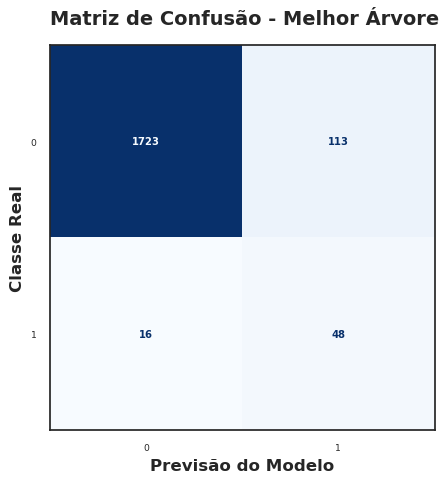


-------------- IMPORTÂNCIA DAS VARIÁVEIS (ÁRVORE) --------------


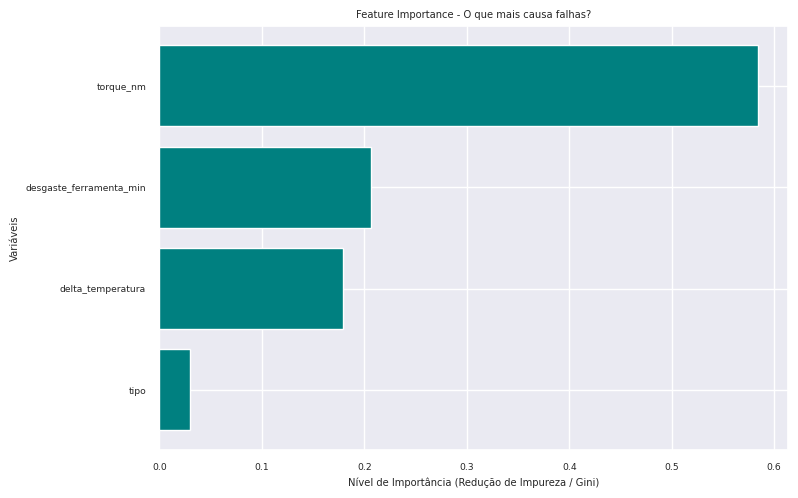

                Feature  Importancia
              torque_nm     0.584625
desgaste_ferramenta_min     0.206416
      delta_temperatura     0.179288
                   tipo     0.029672


In [49]:
# Treinando os modelos campeões com as configurações mais estáveis
melhor_knn = KNeighborsClassifier(n_neighbors=6).fit(X_train_knn, y_train_sm)
melhor_arvore = DecisionTreeClassifier(max_depth=9, random_state=42).fit(X_train_tree, y_train_sm)
print(49*'=')
print(15*'*', 'RESULTADOS FINAIS', 15*'*')
print(49*'=')
print()
print(f"Acurácia Final KNN (Teste): {accuracy_score(y_test, melhor_knn.predict(X_test_knn)):.4f}")
print(f"Acurácia Final Árvore (Teste): {accuracy_score(y_test, melhor_arvore.predict(X_test_tree)):.4f}")

print('\n--- Relatório KNN ---')
print(classification_report(y_test, melhor_knn.predict(X_test_knn)))

print('\n--- Relatório Árvore ---')
print(classification_report(y_test, melhor_arvore.predict(X_test_tree)))

# Matriz de Confusão do modelo escolhido
with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    disp = ConfusionMatrixDisplay.from_estimator(
        melhor_arvore, X_test_tree, y_test, cmap='Blues', ax=ax, colorbar=False
    )
    
    ax.set_title('Matriz de Confusão - Melhor Árvore', fontsize=14, pad=15, fontweight='bold', loc='left')
    ax.set_xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
    ax.set_ylabel('Classe Real', fontsize=12, fontweight='bold')
    
    # Rótulos internos em negrito
    for text in disp.text_.ravel():
        text.set_fontweight('bold')
        
    plt.savefig(pasta_graficos / "matriz_confusao_arvore.png", dpi=300, bbox_inches='tight')
    plt.show()

print()
print(14*'-','IMPORTÂNCIA DAS VARIÁVEIS (ÁRVORE)', 14*'-')

importancias = melhor_arvore.feature_importances_

df_importancias = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importancia': importancias
})

df_importancias = df_importancias.sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_importancias['Feature'], df_importancias['Importancia'], color='teal')
plt.title("Feature Importance - O que mais causa falhas?")
plt.xlabel("Nível de Importância (Redução de Impureza / Gini)")
plt.ylabel("Variáveis")
plt.tight_layout()
plt.savefig(pasta_graficos / "feature_selection.png", dpi=300, bbox_inches='tight')
plt.show()

print(df_importancias.sort_values(by='Importancia', ascending=False).to_string(index=False))

In [48]:
# EXPERIMENTAÇÃO: IMPACTO DA REDUÇÃO DE DIMENSIONALIDADE NO KNN
# Hipótese: A remoção da variável 'tipo' (baixa importância) melhorará o Recall do KNN sem alterar ou melhorar a Acuracia.

print('--- Teste A/B: KNN Original vs. KNN Reduzido ---')

X_train_knn_reduzido = X_train_knn.drop(columns=['tipo'])
X_test_knn_reduzido = X_test_knn.drop(columns=['tipo'])

knn_experimental = KNeighborsClassifier(n_neighbors=8).fit(X_train_knn_reduzido, y_train_sm)

predicoes_original = melhor_knn.predict(X_test_knn)
predicoes_experimental = knn_experimental.predict(X_test_knn_reduzido)

acc_orig = accuracy_score(y_test, predicoes_original)
recall_orig = recall_score(y_test, predicoes_original)

acc_exp = accuracy_score(y_test, predicoes_experimental)
recall_exp = recall_score(y_test, predicoes_experimental)

print(f'KNN Original   -> Acurácia: {acc_orig:.4f} | Recall (Falhas): {recall_orig:.4f}')
print(f'KNN Reduzido   -> Acurácia: {acc_exp:.4f} | Recall (Falhas): {recall_exp:.4f}')

print('\n--- Relatório Completo: KNN Reduzido ---')
print(classification_report(y_test, predicoes_experimental))

--- Teste A/B: KNN Original vs. KNN Reduzido ---
KNN Original   -> Acurácia: 0.9216 | Recall (Falhas): 0.7031
KNN Reduzido   -> Acurácia: 0.9095 | Recall (Falhas): 0.8281

--- Relatório Completo: KNN Reduzido ---
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1836
           1       0.25      0.83      0.38        64

    accuracy                           0.91      1900
   macro avg       0.62      0.87      0.67      1900
weighted avg       0.97      0.91      0.93      1900



`Veredito: Manutenção da Variável tipo`

Embora a exclusão da variável tipo tenha melhorado significativamente o Recall, essa remoção causou uma piora na Acurácia. Como a Acurácia foi definida como a métrica principal deste projeto, a `hipótese nula (H0) não foi rejeitada`. Portanto, a variável será mantida no modelo KNN.

# 9 - Avaliação da Acuracia e Verdito Final

**`Comparativo de Desempenho`**:

Após a etapa de otimização de hiperparâmetros e o combate ao overfitting, ambos os modelos campeões foram avaliados utilizando os dados do conjunto de teste (20% da base). O modelo KNN, em sua configuração mais estável, obteve uma acurácia final de 92,21%. Por sua vez, a Árvore de Decisão com ajuste de max_depth=9 superou esse resultado, alcançando uma acurácia final de 93,21% e somado a isso obtendo um recall superior e com uma diferença menor entre treino e teste de 0.0285 frente ao KNN que foi de 0.0414.

**`Veredito Final`**:

Comparando principalmente as as taxas de acerto -métrica principal deste projeto- somado a desempenho do recall e overfitting, a Árvore de Decisão apresentou o desempenho preditivo superior no conjunto de teste e deve ser o modelo adotado oficialmente.

Além de liderar estatisticamente na métrica principal de acurácia, a adoção da Árvore de Decisão traz vantagens arquiteturais e estratégicas fundamentais para um cenário industrial de manutenção preditiva. Diferente do KNN, que atua realizando cálculos de distâncias geométricas de difícil interpretação, a Árvore de Decisão baseia-se em cortes lógicos. Isso permite extrair a importância das variáveis (Feature Importance), revelando de forma transparente para a equipe de engenharia do chão de fábrica quais fatores mecânicos (como o Torque) estão determinando as falhas. Essa união entre maior assertividade global e explicabilidade de negócios torna a Árvore de Decisão a solução tecnológica ideal para este cenário.